In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('D:\sprints project\selected_data.csv')
df.head()

,PC4,PC5,PC2,PC1,PC8,PC3,PC9,PC7,PC6,PC10,Target
0,2.293052,0.023175,-1.087655,1.130664,-0.536787,3.164263,-1.495392,0.664854,0.578814,-0.499485,0
1,-0.857970,-0.006289,-1.417885,3.190926,1.069777,-0.533715,0.342524,-0.259063,0.745347,1.431509,2
2,-0.626641,0.152793,0.657008,3.124339,0.209299,-0.285134,0.043205,-0.324995,1.130179,0.462304,1
3,2.832741,0.721309,1.410972,-0.484339,-2.153525,0.397806,0.760079,-0.522221,-0.388361,0.228379,0
4,1.209318,0.770835,-0.330033,-2.284542,0.014736,-0.072260,1.050381,0.379567,0.625587,0.628110,0


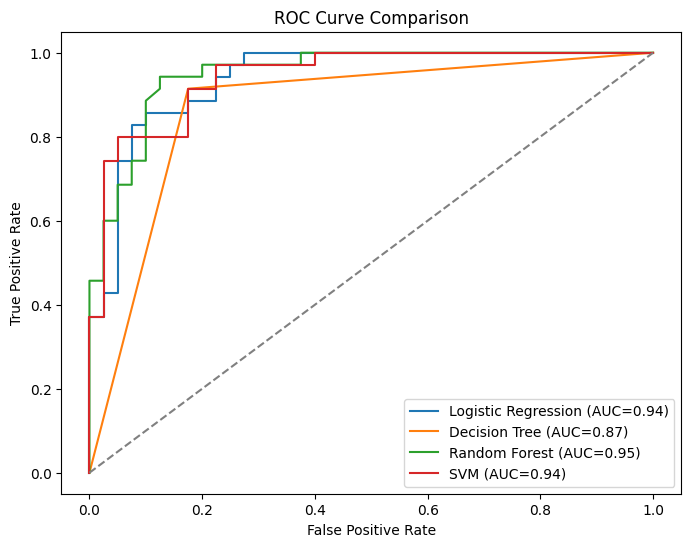

Model Evaluation Results:
                      Accuracy  Precision    Recall  F1-score       AUC
Logistic Regression  0.866667   0.857143  0.857143  0.857143  0.940714
Decision Tree        0.866667   0.820513  0.914286  0.864865  0.869643
Random Forest        0.880000   0.882353  0.857143  0.869565  0.950357
SVM                  0.840000   0.848485  0.800000  0.823529  0.943571


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve

df["Target"] = df["Target"].apply(lambda x: 0 if x == 0 else 1)
X = df.drop(columns=['Target'])
y = df['Target']

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,stratify=y)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}
results = {}

plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1, "AUC": auc}

    # ROC curve
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")


plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

results_df = pd.DataFrame(results).T
print("Model Evaluation Results:\n", results_df)